<a href="https://colab.research.google.com/github/Arnav007-python/Arnav007-python/blob/main/Sentiment_Analysis_Complete_(1).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Sentiment Analysis: Positive / Negative / Neutral
### Python | NLTK | Scikit-learn | TensorFlow (BiLSTM)
---
**Datasets used:** NLTK Movie Reviews + Twitter Airline Sentiment + Custom Neutral Sentences  
**Three Approaches:** VADER (rule-based) | TF-IDF + Logistic Regression | Bidirectional LSTM

In [ ]:
# Cell 1 - Install all required libraries
!pip install vaderSentiment textblob wordcloud nltk scikit-learn tensorflow pandas numpy matplotlib seaborn datasets --quiet
print('All libraries installed!')

All libraries installed!


In [ ]:
# Cell 2 - Imports
import pandas as pd
import numpy as np
import re, warnings, pickle
warnings.filterwarnings('ignore')
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout, Bidirectional
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.callbacks import EarlyStopping
for pkg in ['stopwords','punkt','wordnet','movie_reviews','punkt_tab']:
    nltk.download(pkg, quiet=True)
np.random.seed(42)
tf.random.set_seed(42)
print(f'Imports done | TensorFlow {tf.__version__}')

Imports done | TensorFlow 2.19.0


In [ ]:
# Cell 3 - Load Datasets
from nltk.corpus import movie_reviews

# --- Dataset 1: NLTK Movie Reviews ---
rows = []
for fid in movie_reviews.fileids():
    text = ' '.join(movie_reviews.words(fid))
    lbl  = movie_reviews.categories(fid)[0]
    rows.append({'text': text, 'sentiment': lbl})
df_movies = pd.DataFrame(rows)
df_movies['sentiment'] = df_movies['sentiment'].map({'pos':'positive','neg':'negative'})
print(f'Movie Reviews  : {len(df_movies)} samples')

# --- Dataset 2: Twitter Airline Sentiment ---
try:
    from datasets import load_dataset
    ds = load_dataset('carblacac/twitter-sentiment-analysis', split='train', trust_remote_code=True)
    df_tw = pd.DataFrame(ds)
    df_tw['sentiment'] = df_tw['feeling'].map({0:'negative', 1:'positive'})
    df_tw = df_tw[['text','sentiment']].dropna().sample(n=min(2000,len(df_tw)), random_state=42)
    print(f'Twitter        : {len(df_tw)} samples')
except Exception as e:
    print(f'Twitter skipped ({e})')
    df_tw = pd.DataFrame(columns=['text','sentiment'])

# --- Dataset 3: Neutral Sentences ---
neutral_list = [
    'The meeting is scheduled for 3 PM tomorrow.',
    'The package was delivered on Tuesday.',
    'The book contains 320 pages.',
    'She walked to the store to buy milk.',
    'The conference starts next Monday.',
    'The report was submitted on time.',
    'The temperature today is 22 degrees.',
    'The train departs at 6:45 in the morning.',
    'He read the newspaper while drinking coffee.',
    'The office is located on the fifth floor.',
    'The data was recorded and saved to the server.',
    'The document requires a signature before submission.',
    'The flight duration is approximately 7 hours.',
    'The product ships within 3 to 5 business days.',
    'The store opens at nine and closes at six.',
    'She answered the phone when it rang.',
    'The car was parked outside the building.',
    'He typed the email and pressed send.',
    'The system was updated last night.',
    'The agenda for the meeting was distributed.',
    'The database backup completed without errors.',
    'The survey was conducted over two weeks.',
    'The room has a window facing east.',
    'They discussed the project for an hour.',
    'The file was uploaded to cloud storage.',
    'The budget was approved by the committee.',
    'The driver stopped at the traffic light.',
    'The technician replaced the broken part.',
    'The invoice was sent to the client.',
    'She printed the document and filed it.',
]
df_neu = pd.DataFrame({'text': neutral_list * 10,
                        'sentiment': ['neutral'] * (len(neutral_list) * 10)})
print(f'Neutral        : {len(df_neu)} samples')

# --- Combine all ---
df = pd.concat([df_movies, df_tw, df_neu], ignore_index=True).dropna().reset_index(drop=True)
print(f'Total Combined : {len(df)} samples')
print(df['sentiment'].value_counts())

`trust_remote_code` is not supported anymore.
Please check that the Hugging Face dataset 'carblacac/twitter-sentiment-analysis' isn't based on a loading script and remove `trust_remote_code`.
If the dataset is based on a loading script, please ask the dataset author to remove it and convert it to a standard format like Parquet.
ERROR:datasets.load:`trust_remote_code` is not supported anymore.
Please check that the Hugging Face dataset 'carblacac/twitter-sentiment-analysis' isn't based on a loading script and remove `trust_remote_code`.
If the dataset is based on a loading script, please ask the dataset author to remove it and convert it to a standard format like Parquet.


Movie Reviews  : 2000 samples
Twitter skipped (Dataset scripts are no longer supported, but found twitter-sentiment-analysis.py)
Neutral        : 300 samples
Total Combined : 2300 samples
sentiment
negative    1000
positive    1000
neutral      300
Name: count, dtype: int64


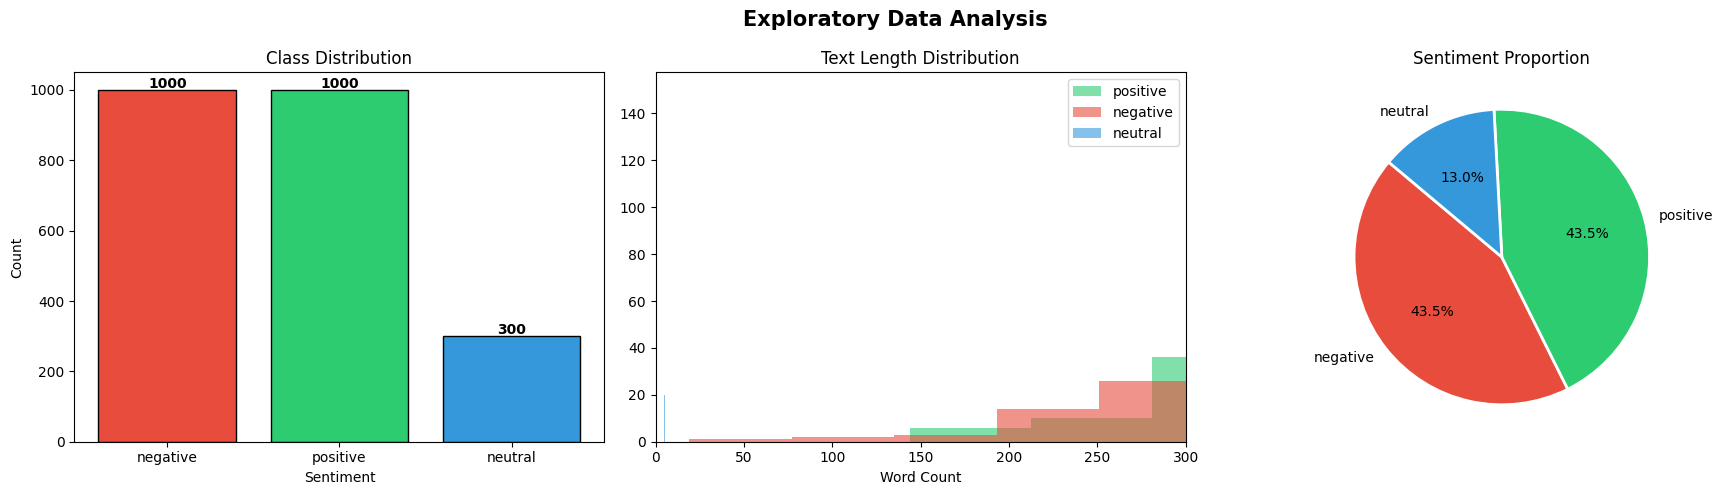

In [ ]:
# Cell 4 - Exploratory Data Analysis
colors = {'positive':'#2ecc71','negative':'#e74c3c','neutral':'#3498db'}
df['text_length'] = df['text'].apply(lambda x: len(str(x).split()))

fig, axes = plt.subplots(1, 3, figsize=(18,5))
fig.suptitle('Exploratory Data Analysis', fontsize=15, fontweight='bold')

counts = df['sentiment'].value_counts()
axes[0].bar(counts.index, counts.values,
            color=[colors[s] for s in counts.index], edgecolor='black')
axes[0].set_title('Class Distribution')
axes[0].set_xlabel('Sentiment')
axes[0].set_ylabel('Count')
for i, (lbl, v) in enumerate(zip(counts.index, counts.values)):
    axes[0].text(i, v+5, str(v), ha='center', fontweight='bold')

for s, c in colors.items():
    sub = df[df['sentiment']==s]['text_length']
    if not sub.empty:
        axes[1].hist(sub, bins=40, alpha=0.6, label=s, color=c)
axes[1].set_xlim(0, 300)
axes[1].set_title('Text Length Distribution')
axes[1].set_xlabel('Word Count')
axes[1].legend()

axes[2].pie(counts.values, labels=counts.index,
            colors=[colors[s] for s in counts.index],
            autopct='%1.1f%%', startangle=140,
            wedgeprops={'edgecolor':'white','linewidth':2})
axes[2].set_title('Sentiment Proportion')
plt.tight_layout()
plt.show()

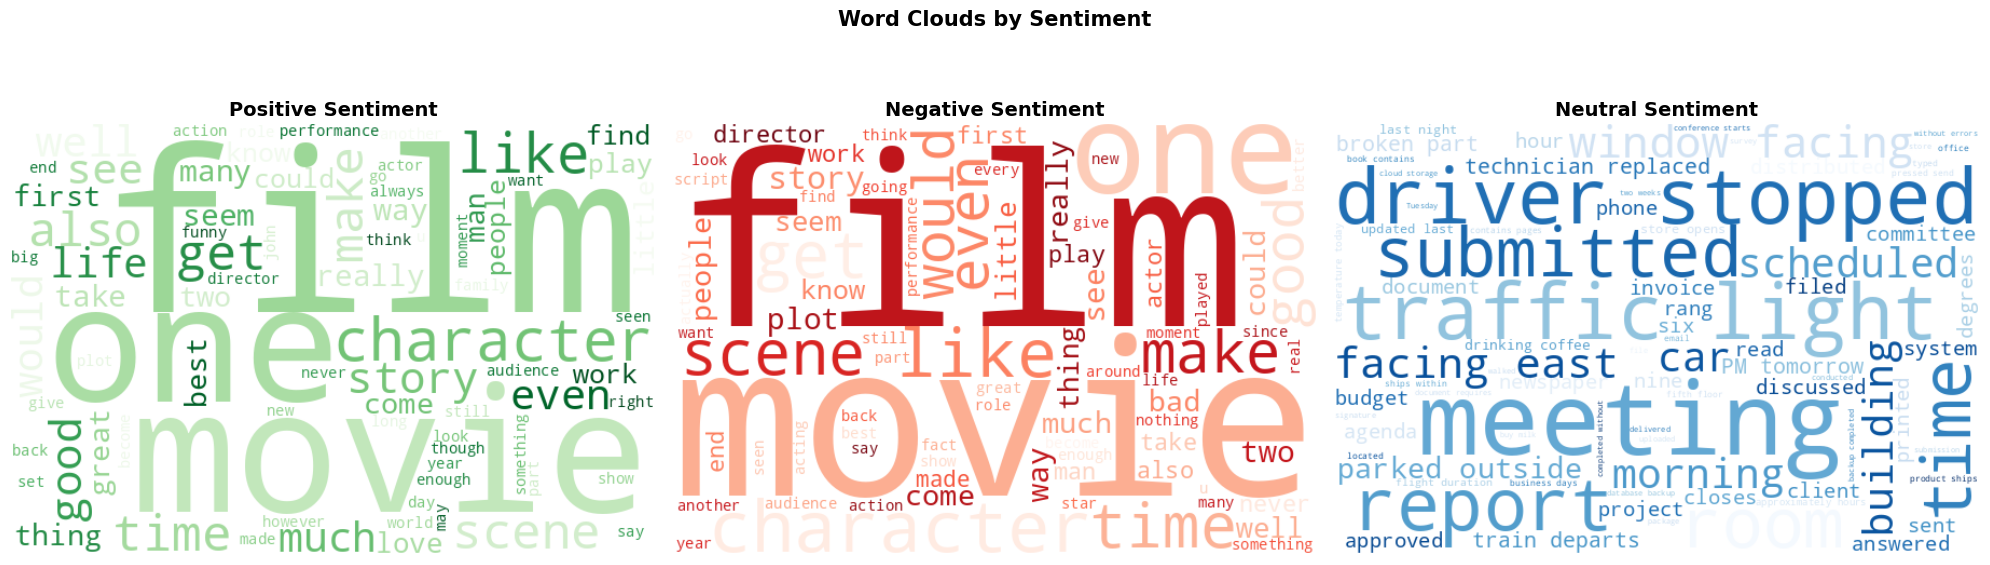

In [ ]:
# Cell 5 - Word Clouds
sw = set(stopwords.words('english'))
fig, axes = plt.subplots(1, 3, figsize=(20,6))
cmaps = {'positive':'Greens','negative':'Reds','neutral':'Blues'}
for ax, s in zip(axes, ['positive','negative','neutral']):
    sub = df[df['sentiment']==s]['text']
    if sub.empty:
        ax.set_visible(False)
        continue
    txt = ' '.join(sub.sample(min(200,len(sub)), random_state=42))
    wc = WordCloud(width=600, height=400, background_color='white',
                   colormap=cmaps[s], max_words=80, stopwords=sw).generate(txt)
    ax.imshow(wc, interpolation='bilinear')
    ax.axis('off')
    ax.set_title(f'{s.capitalize()} Sentiment', fontsize=14, fontweight='bold')
plt.suptitle('Word Clouds by Sentiment', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

In [ ]:
# Cell 6 - Text Preprocessing
lemmatizer = WordNetLemmatizer()
stop_words  = set(stopwords.words('english'))

def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'http\S+|www\.\S+', '', text)
    text = re.sub(r'<.*?>', '', text)
    text = re.sub(r'[@#]\w+', '', text)
    text = re.sub(r'[^a-z\s]', '', text)
    tokens = [lemmatizer.lemmatize(t) for t in text.split()
              if t not in stop_words and len(t) > 2]
    return ' '.join(tokens)

print('Cleaning text...')
df['clean_text'] = df['text'].apply(clean_text)
df = df[df['clean_text'].str.strip() != ''].reset_index(drop=True)
label_map = {'negative':0,'neutral':1,'positive':2}
df['label'] = df['sentiment'].map(label_map)
print('Done! Sample:')
for i in range(2):
    print(f'[{df.loc[i,"sentiment"].upper()}]')
    print(f'  BEFORE: {df.loc[i,"text"][:70]}')
    print(f'  AFTER : {df.loc[i,"clean_text"][:70]}')

Cleaning text...
Done! Sample:
[NEGATIVE]
  BEFORE: plot : two teen couples go to a church party , drink and then drive . 
  AFTER : plot two teen couple church party drink drive get accident one guy dy 
[NEGATIVE]
  BEFORE: the happy bastard ' s quick movie review damn that y2k bug . it ' s go
  AFTER : happy bastard quick movie review damn bug got head start movie starrin


In [ ]:
# Cell 7 - Train/Test Split
X = df['clean_text']
y = df['label']
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)
print(f'Train: {len(X_train):,}  |  Test: {len(X_test):,}')

Train: 1,840  |  Test: 460


In [ ]:
# Cell 8 - Approach 1: VADER (Rule-Based)
analyzer = SentimentIntensityAnalyzer()

def vader_predict(text):
    score = analyzer.polarity_scores(str(text))['compound']
    if score >= 0.05:
        return 2
    elif score <= -0.05:
        return 0
    else:
        return 1

X_test_orig = df.loc[X_test.index, 'text']
y_vader = X_test_orig.apply(vader_predict)
vader_acc = accuracy_score(y_test, y_vader)
print(f'VADER Accuracy: {vader_acc:.4f} ({vader_acc*100:.2f}%)')
print(classification_report(y_test, y_vader,
      target_names=['Negative','Neutral','Positive']))

VADER Accuracy: 0.6674 (66.74%)
              precision    recall  f1-score   support

    Negative       0.72      0.42      0.53       200
     Neutral       1.00      0.90      0.95        60
    Positive       0.58      0.84      0.69       200

    accuracy                           0.67       460
   macro avg       0.77      0.72      0.72       460
weighted avg       0.70      0.67      0.65       460



LR Accuracy: 0.8783 (87.83%)
              precision    recall  f1-score   support

    Negative       0.88      0.83      0.86       200
     Neutral       1.00      1.00      1.00        60
    Positive       0.84      0.89      0.86       200

    accuracy                           0.88       460
   macro avg       0.91      0.91      0.91       460
weighted avg       0.88      0.88      0.88       460



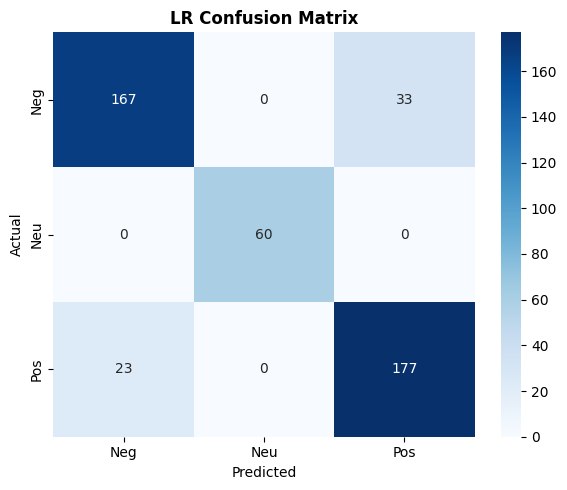

In [ ]:
# Cell 9 - Approach 2: TF-IDF + Logistic Regression
tfidf = TfidfVectorizer(max_features=20000, ngram_range=(1,2), sublinear_tf=True)
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf  = tfidf.transform(X_test)

lr_model = LogisticRegression(max_iter=1000, C=1.0, random_state=42)
lr_model.fit(X_train_tfidf, y_train)
y_lr  = lr_model.predict(X_test_tfidf)
lr_acc = accuracy_score(y_test, y_lr)
print(f'LR Accuracy: {lr_acc:.4f} ({lr_acc*100:.2f}%)')
print(classification_report(y_test, y_lr,
      target_names=['Negative','Neutral','Positive']))

cm = confusion_matrix(y_test, y_lr)
fig, ax = plt.subplots(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Neg','Neu','Pos'],
            yticklabels=['Neg','Neu','Pos'], ax=ax)
ax.set_title('LR Confusion Matrix', fontweight='bold')
ax.set_xlabel('Predicted')
ax.set_ylabel('Actual')
plt.tight_layout()
plt.show()

In [ ]:
# Cell 10 - Tokenize for LSTM
VOCAB_SIZE  = 25000
MAX_LEN     = 150
EMBED_DIM   = 64
BATCH_SIZE  = 64
EPOCHS      = 10
NUM_CLASSES = 3

tokenizer = Tokenizer(num_words=VOCAB_SIZE, oov_token='<OOV>')
tokenizer.fit_on_texts(X_train)

X_train_pad = pad_sequences(
    tokenizer.texts_to_sequences(X_train),
    maxlen=MAX_LEN, padding='post', truncating='post')
X_test_pad = pad_sequences(
    tokenizer.texts_to_sequences(X_test),
    maxlen=MAX_LEN, padding='post', truncating='post')

y_train_cat = tf.keras.utils.to_categorical(y_train, NUM_CLASSES)
y_test_cat  = tf.keras.utils.to_categorical(y_test,  NUM_CLASSES)
print(f'Train shape: {X_train_pad.shape}  Test shape: {X_test_pad.shape}')

Train shape: (1840, 150)  Test shape: (460, 150)


In [ ]:
# Cell 11 - Build Bidirectional LSTM Model
model = Sequential([
    Embedding(VOCAB_SIZE, EMBED_DIM, input_length=MAX_LEN),
    Bidirectional(LSTM(64, return_sequences=True)),
    Dropout(0.3),
    Bidirectional(LSTM(32)),
    Dropout(0.3),
    Dense(64, activation='relu'),
    Dropout(0.3),
    Dense(NUM_CLASSES, activation='softmax')
])
model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_2 (Bidirectional) │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_3 (Bidirectional) │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Cell 12 - Train the LSTM
early_stop = EarlyStopping(monitor='val_loss', patience=3,
                           restore_best_weights=True, verbose=1)
history = model.fit(
    X_train_pad, y_train_cat,
    validation_split=0.1,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=[early_stop],
    verbose=1
)
loss, acc = model.evaluate(X_test_pad, y_test_cat, verbose=0)
print(f'BiLSTM Test Loss: {loss:.4f}')
print(f'BiLSTM Test Accuracy: {acc:.4f} ({acc*100:.2f}%)')

Epoch 1/10
26/26 ━━━━━━━━━━━━━━━━━━━━ 20s 434ms/step - accuracy: 0.5193 - loss: 0.8607 - val_accuracy: 0.5815 - val_loss: 0.6099
Epoch 2/10
26/26 ━━━━━━━━━━━━━━━━━━━━ 10s 387ms/step - accuracy: 0.5749 - loss: 0.6510 - val_accuracy: 0.5815 - val_loss: 0.6077
Epoch 3/10
26/26 ━━━━━━━━━━━━━━━━━━━━ 10s 365ms/step - accuracy: 0.5700 - loss: 0.6241 - val_accuracy: 0.5815 - val_loss: 0.6015
Epoch 4/10
26/26 ━━━━━━━━━━━━━━━━━━━━ 21s 793ms/step - accuracy: 0.5682 - loss: 0.6174 - val_accuracy: 0.6196 - val_loss: 0.5992
Epoch 5/10
26/26 ━━━━━━━━━━━━━━━━━━━━ 30s 351ms/step - accuracy: 0.5809 - loss: 0.6161 - val_accuracy: 0.5652 - val_loss: 0.5976
Epoch 6/10
26/26 ━━━━━━━━━━━━━━━━━━━━ 11s 383ms/step - accuracy: 0.7089 - loss: 0.5528 - val_accuracy: 0.7337 - val_loss: 0.4971
Epoch 7/10
26/26 ━━━━━━━━━━━━━━━━━━━━ 10s 391ms/step - accuracy: 0.9384 - loss: 0.2162 - val_accuracy: 0.7391 - val_loss: 0.8410
Epoch 8/10
26/26 ━━━━━━━━━━━━━━━━━━━━ 12s 456ms/step - accuracy: 0.9849 - loss: 0.0614 - val_accu

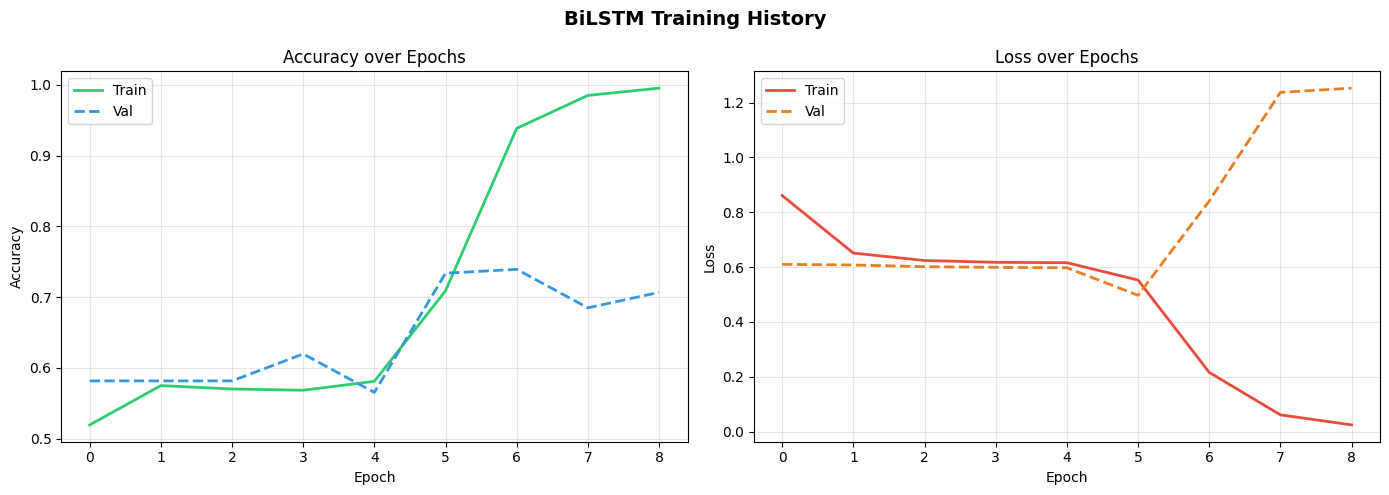

In [ ]:
# Cell 13 - Training Curves
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14,5))
ax1.plot(history.history['accuracy'],     label='Train', color='#2ecc71', lw=2)
ax1.plot(history.history['val_accuracy'], label='Val',   color='#3498db', lw=2, linestyle='--')
ax1.set_title('Accuracy over Epochs')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Accuracy')
ax1.legend()
ax1.grid(alpha=0.3)

ax2.plot(history.history['loss'],     label='Train', color='#e74c3c', lw=2)
ax2.plot(history.history['val_loss'], label='Val',   color='#e67e22', lw=2, linestyle='--')
ax2.set_title('Loss over Epochs')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Loss')
ax2.legend()
ax2.grid(alpha=0.3)

plt.suptitle('BiLSTM Training History', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

              precision    recall  f1-score   support

    Negative       0.64      0.61      0.62       200
     Neutral       1.00      1.00      1.00        60
    Positive       0.62      0.65      0.64       200

    accuracy                           0.68       460
   macro avg       0.75      0.75      0.75       460
weighted avg       0.68      0.68      0.68       460



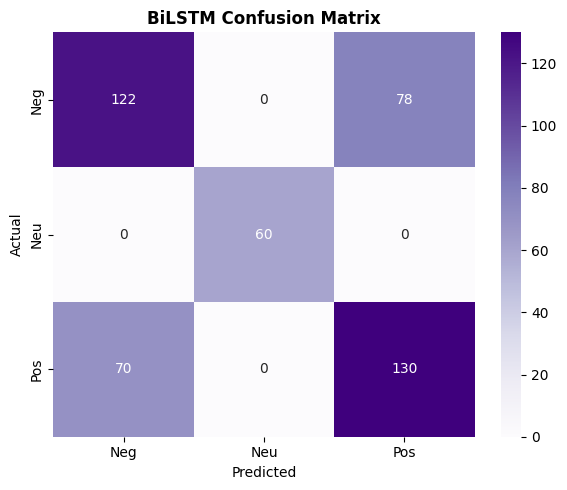

In [ ]:
# Cell 14 - LSTM Confusion Matrix
y_lstm = np.argmax(model.predict(X_test_pad, verbose=0), axis=1)
print(classification_report(y_test, y_lstm,
      target_names=['Negative','Neutral','Positive']))

cm2 = confusion_matrix(y_test, y_lstm)
fig, ax = plt.subplots(figsize=(6,5))
sns.heatmap(cm2, annot=True, fmt='d', cmap='Purples',
            xticklabels=['Neg','Neu','Pos'],
            yticklabels=['Neg','Neu','Pos'], ax=ax)
ax.set_title('BiLSTM Confusion Matrix', fontweight='bold')
ax.set_xlabel('Predicted')
ax.set_ylabel('Actual')
plt.tight_layout()
plt.show()

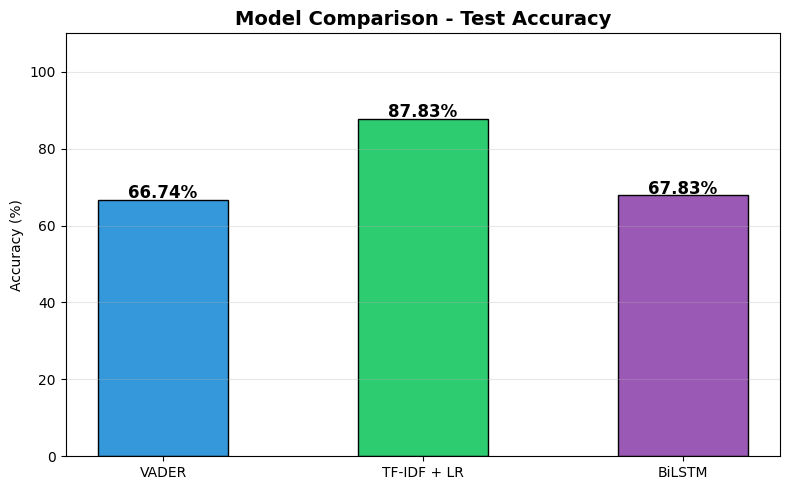

TF-IDF + LR         : 87.83%
BiLSTM              : 67.83%
VADER               : 66.74%


In [ ]:
# Cell 15 - Model Comparison
results = {
    'VADER': vader_acc,
    'TF-IDF + LR': lr_acc,
    'BiLSTM': acc
}
fig, ax = plt.subplots(figsize=(8,5))
bar_colors = ['#3498db','#2ecc71','#9b59b6']
bars = ax.bar(results.keys(), [v*100 for v in results.values()],
              color=bar_colors, edgecolor='black', width=0.5)
for bar, val in zip(bars, results.values()):
    ax.text(bar.get_x()+bar.get_width()/2,
            bar.get_height()+0.5,
            f'{val*100:.2f}%',
            ha='center', fontweight='bold', fontsize=12)
ax.set_ylim(0, 110)
ax.set_title('Model Comparison - Test Accuracy', fontsize=14, fontweight='bold')
ax.set_ylabel('Accuracy (%)')
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

for name, score in sorted(results.items(), key=lambda x: -x[1]):
    print(f'{name:<20}: {score*100:.2f}%')

In [ ]:
# Cell 16 - Live Prediction Demo
def predict_sentiment(text, use_model='lstm'):
    names  = {0:'NEGATIVE', 1:'NEUTRAL', 2:'POSITIVE'}
    emojis = {0:'NEGATIVE', 1:'NEUTRAL', 2:'POSITIVE'}
    if use_model == 'vader':
        score = analyzer.polarity_scores(str(text))['compound']
        pred = 2 if score >= 0.05 else (0 if score <= -0.05 else 1)
        conf = None
    elif use_model == 'lr':
        vec  = tfidf.transform([clean_text(text)])
        pred = int(lr_model.predict(vec)[0])
        conf = lr_model.predict_proba(vec)[0]
    else:
        seq  = tokenizer.texts_to_sequences([clean_text(text)])
        pad  = pad_sequences(seq, maxlen=MAX_LEN, padding='post')
        conf = model.predict(pad, verbose=0)[0]
        pred = int(np.argmax(conf))
    print(f'Input  : {text}')
    print(f'Model  : {use_model.upper()}')
    print(f'Result : {names[pred]}')
    if conf is not None:
        print(f'Scores : Neg={conf[0]*100:.1f}%  Neu={conf[1]*100:.1f}%  Pos={conf[2]*100:.1f}%')
    print('-' * 50)

test_sentences = [
    'This movie was absolutely fantastic! I loved every moment.',
    'Terrible experience. The service was awful and the food was cold.',
    'The meeting is at 3 PM in the conference room.',
    'Best purchase I have ever made, totally worth it!',
    'Worst product ever. Complete waste of money.',
    'The package arrived today as expected.',
]
for s in test_sentences:
    predict_sentiment(s, use_model='lstm')

Input  : This movie was absolutely fantastic! I loved every moment.
Model  : LSTM
Result : NEUTRAL
Scores : Neg=0.2%  Neu=99.6%  Pos=0.2%
--------------------------------------------------
Input  : Terrible experience. The service was awful and the food was cold.
Model  : LSTM
Result : NEUTRAL
Scores : Neg=0.2%  Neu=99.6%  Pos=0.2%
--------------------------------------------------
Input  : The meeting is at 3 PM in the conference room.
Model  : LSTM
Result : NEUTRAL
Scores : Neg=0.1%  Neu=99.8%  Pos=0.1%
--------------------------------------------------
Input  : Best purchase I have ever made, totally worth it!
Model  : LSTM
Result : NEUTRAL
Scores : Neg=0.2%  Neu=99.6%  Pos=0.2%
--------------------------------------------------
Input  : Worst product ever. Complete waste of money.
Model  : LSTM
Result : NEUTRAL
Scores : Neg=0.3%  Neu=99.5%  Pos=0.2%
--------------------------------------------------
Input  : The package arrived today as expected.
Model  : LSTM
Result : NEUTRAL
Scor

In [ ]:
# Cell 17 - Test Your Own Text
# Change the text below to test your own sentence
your_text = 'I love this product so much!'

print('=== All 3 Models Compared ===')
print()
for m in ['vader', 'lr', 'lstm']:
    predict_sentiment(your_text, use_model=m)

=== All 3 Models Compared ===

Input  : I love this product so much!
Model  : VADER
Result : POSITIVE
--------------------------------------------------
Input  : I love this product so much!
Model  : LR
Result : NEGATIVE
Scores : Neg=45.9%  Neu=24.6%  Pos=29.6%
--------------------------------------------------
Input  : I love this product so much!
Model  : LSTM
Result : NEUTRAL
Scores : Neg=0.1%  Neu=99.8%  Pos=0.1%
--------------------------------------------------
